# DLthon 스타일 전용 검색 — 최종 안정화 Colab 실행본

이 노트북은 **사물이 아니라 그림체와 질감**을 검색합니다. 기존 v2의 CLIP·저층 Gram·
group-balanced 프로토타입 계산은 유지하고, Query Rewriting의 캐시·관측·오류 처리를
보강했습니다.

```text
한국어 입력
 → rewrite_query: 내용/스타일 분리 또는 canonical fast path
 → text_search: style_prompt만 사용
 → extract_image_features: 캐시된 스타일 프로토타입 선택
 → final_image_search: Text + CLIP + Gram 결합
 → group 중복 없는 Top 5
```

### Drive 프로젝트 폴더에 필요한 파일

- `daypack_v2.zip`
- `style_search_final_code.zip`

기존 `LLM-Rewrite-v2` 기준선은 보존되어 있습니다. 이 노트북의 rewrite mode를 바꾸면
서로 다른 실험 방법으로 기록해야 합니다.

## 1. GPU와 사용자 설정

Colab 메뉴에서 `런타임 → 런타임 유형 변경 → T4 GPU`를 선택하세요.

- `llm`: 기존 LLM 재작성 기준선과 비교하기 위한 기본값
- `canonical_first`: 명확한 스타일은 API 없이 처리하고 모호한 문장만 LLM 사용
- `canonical_only`: API 키 없이 등록된 스타일 키워드만 검색

처음에는 `llm`을 유지해 기준선을 측정하고, `canonical_first`는 별도 방법으로 비교하세요.

In [1]:
MY_NAME = "김수경"
STYLE_QUERY = "수묵화 스타일의 사과"

# 베이스라인 재현 기본값. canonical_first는 별도 실험 이름으로 비교한다.
REWRITE_MODE = "llm"  # "llm" | "canonical_first" | "canonical_only"
REWRITE_LLM_MODEL = "gpt-5.6-luna"

STAGE1_TOP_K = 50
FINAL_TOP_K = 5
PROTOTYPE_TOP_N = 1
STYLE_TEXT_WEIGHT = 0.30
STYLE_CLIP_WEIGHT = 0.30
STYLE_GRAM_WEIGHT = 0.40

PROJECT_FOLDER_NAMES = ["DLthon_RAG", "DLthon_그림체RAG"]
METHOD_NAME = f"STYLE_FINAL_{REWRITE_MODE}_t{STYLE_TEXT_WEIGHT:.2f}_c{STYLE_CLIP_WEIGHT:.2f}_g{STYLE_GRAM_WEIGHT:.2f}"

print("이름:", MY_NAME)
print("검색어:", STYLE_QUERY)
print("방법:", METHOD_NAME)
print("LLM:", REWRITE_LLM_MODEL if REWRITE_MODE != "canonical_only" else "사용 안 함")

이름: 김수경
검색어: 수묵화 스타일의 사과
방법: STYLE_FINAL_llm_t0.30_c0.30_g0.40
LLM: gpt-5.6-luna


In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU가 활성화되지 않았습니다. 런타임 → 런타임 유형 변경 → T4 GPU를 선택하세요."
    )
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


## 2. Drive 연결과 프로젝트 폴더 탐색

Drive 폴더 후보 중 데이터 ZIP과 코드 ZIP을 모두 가진 폴더를 선택합니다. 폴더를 찾지
못하면 두 파일이 같은 `DLthon_RAG` 폴더 안에 있는지 확인하세요.

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
import os
from pathlib import Path

drive_roots = [Path("/content/drive/MyDrive")]
shared_root = Path("/content/drive/Shareddrives")
if shared_root.is_dir():
    drive_roots.extend(path for path in shared_root.iterdir() if path.is_dir())

candidates = []
for drive_root in drive_roots:
    for name in PROJECT_FOLDER_NAMES:
        direct = drive_root / name
        if direct.is_dir():
            candidates.append(direct)
        candidates.extend(path for path in drive_root.glob(f"*/{name}") if path.is_dir())

def find_code_source(folder):
    code_zip = list(folder.rglob("style_search_final_code.zip"))
    if code_zip:
        return code_zip[0]
    final_files = list(folder.rglob("style_only_hybrid_langgraph_pipeline_final.py"))
    v2_files = list(folder.rglob("style_only_hybrid_langgraph_pipeline_v2.py"))
    base_files = list(folder.rglob("style_hybrid_langgraph_pipeline.py"))
    if final_files and v2_files and base_files:
        return (final_files[0], v2_files[0], base_files[0])
    return None

ready = []
for folder in dict.fromkeys(candidates):
    data_zip = folder / "daypack_v2.zip"
    code_source = find_code_source(folder)
    if data_zip.is_file() and code_source is not None:
        ready.append((folder, data_zip, code_source))

if not ready:
    found = "\n".join(f"- {folder}" for folder in candidates) or "- 후보 폴더 없음"
    raise SystemExit(
        "daypack_v2.zip과 style_search_final_code.zip을 함께 가진 프로젝트 폴더가 없습니다.\n"
        f"찾은 후보:\n{found}"
    )

PROJECT_DIR, DATA_ZIP, CODE_SOURCE = ready[0]
print("프로젝트:", PROJECT_DIR)
print("데이터:", DATA_ZIP.name)
print("코드:", CODE_SOURCE if isinstance(CODE_SOURCE, Path) else [p.name for p in CODE_SOURCE])

프로젝트: /content/drive/MyDrive/DLthon_RAG
데이터: daypack_v2.zip
코드: /content/drive/MyDrive/DLthon_RAG/style_search_final_code.zip


## 3. 패키지 설치

PyTorch와 torchvision은 Colab GPU 런타임에 설치된 버전을 그대로 사용합니다. LangGraph,
LLM 연결 모듈, Sentence Transformers만 설치합니다.

In [9]:
%pip -q install \
    "langgraph>=1.0,<2" \
    "langchain-openai>=1.0,<2" \
    "sentence-transformers>=3,<6"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.2/122.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 44.6 MB/s eta 0:00:00


In [10]:
from importlib.metadata import version

for package in ["langgraph", "langchain-openai", "sentence-transformers", "torch", "torchvision"]:
    print(f"{package:24s}", version(package))

langgraph                1.2.9
langchain-openai         1.4.2
sentence-transformers    5.6.0
torch                    2.11.0+cu128
torchvision              0.26.0+cu128


## 4. 데이터와 코드 안전하게 준비

ZIP 내부에 상위 폴더가 한 겹 더 있어도 marker 파일로 실제 루트를 찾습니다. 경로 이탈이
있는 ZIP은 중단합니다. 데이터·코드는 Colab 로컬에 풀고, 큰 특징 캐시는 Drive에 저장합니다.

In [11]:
import shutil
import sys
import tempfile
import zipfile

def extract_zip_safe(zip_path, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            relative = member.filename.replace("\\", "/").lstrip("/")
            if not relative:
                continue
            target = (destination / relative).resolve()
            if target != destination and destination not in target.parents:
                raise RuntimeError(f"안전하지 않은 ZIP 경로: {member.filename}")
            if member.is_dir() or relative.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with archive.open(member) as source_stream, target.open("wb") as output_stream:
                    shutil.copyfileobj(source_stream, output_stream)

def find_marked_root(search_root, markers):
    matches = []
    for root, directories, files in os.walk(search_root):
        present = set(directories) | set(files)
        if all(marker in present for marker in markers):
            matches.append(Path(root))
    if len(matches) != 1:
        raise RuntimeError(f"marker root를 하나로 정하지 못했습니다: {markers}, {matches}")
    return matches[0]

local_data = Path("/content/daypack_v2")
local_code = Path("/content/style_search_final")
staging = Path(tempfile.mkdtemp(prefix="style_search_setup_", dir="/content"))
try:
    data_stage = staging / "data"
    extract_zip_safe(DATA_ZIP, data_stage)
    detected_data = find_marked_root(data_stage, ["meta.csv", "VERSION.json", "images"])
    if local_data.is_dir():
        shutil.rmtree(local_data)
    shutil.copytree(detected_data, local_data)

    if local_code.is_dir():
        shutil.rmtree(local_code)
    local_code.mkdir(parents=True)
    if isinstance(CODE_SOURCE, Path):
        code_stage = staging / "code"
        extract_zip_safe(CODE_SOURCE, code_stage)
        required_names = [
            "style_hybrid_langgraph_pipeline.py",
            "style_only_hybrid_langgraph_pipeline_v2.py",
            "style_only_hybrid_langgraph_pipeline_final.py",
        ]
        for name in required_names:
            detected = list(code_stage.rglob(name))
            if len(detected) != 1:
                raise RuntimeError(f"코드 ZIP에서 {name}을 하나로 찾지 못했습니다: {detected}")
            shutil.copy2(detected[0], local_code / name)
    else:
        for source_path in CODE_SOURCE:
            shutil.copy2(source_path, local_code / source_path.name)
finally:
    shutil.rmtree(staging, ignore_errors=True)

required = [
    local_data / "meta.csv",
    local_data / "VERSION.json",
    local_data / "images",
    local_code / "style_hybrid_langgraph_pipeline.py",
    local_code / "style_only_hybrid_langgraph_pipeline_v2.py",
    local_code / "style_only_hybrid_langgraph_pipeline_final.py",
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise RuntimeError("준비 후 필요한 파일이 없습니다:\n" + "\n".join(missing))

if str(local_code) not in sys.path:
    sys.path.insert(0, str(local_code))
print("데이터 준비:", local_data)
print("코드 준비:", local_code)

데이터 준비: /content/daypack_v2
코드 준비: /content/style_search_final


In [12]:
import csv

with (local_data / "meta.csv").open(encoding="utf-8") as stream:
    meta_rows = list(csv.DictReader(stream))
styles = sorted({row["style"] for row in meta_rows})
if len(meta_rows) != 2522 or len(styles) != 20:
    raise RuntimeError(
        f"daypack_v2 구성이 예상과 다릅니다: 이미지={len(meta_rows)}, 스타일={len(styles)}"
    )
print("데이터 검증 완료:", len(meta_rows), "장 /", len(styles), "스타일")

데이터 검증 완료: 2522 장 / 20 스타일


## 5. API 키 연결

`llm`과 `canonical_first`에서는 Colab 왼쪽 열쇠 모양 `Secrets`에 `OPENAI_API_KEY`를
저장하고 Notebook access를 켜세요. `canonical_only`는 이 셀을 그대로 실행해도 키를
요청하지 않습니다. 키 값은 출력하거나 결과 파일에 저장하지 않습니다.

In [17]:
import getpass

if REWRITE_MODE == "canonical_only":
    print("canonical_only: OpenAI API 키를 사용하지 않습니다.")
else:
    from google.colab import userdata

    try:
        api_key = userdata.get("OPENAI_API_KEY")
    except Exception:
        api_key = None
    if not api_key:
        api_key = getpass.getpass("OPENAI_API_KEY: ")
    if not api_key:
        raise RuntimeError("현재 rewrite mode에는 API 키가 필요합니다.")
    os.environ["OPENAI_API_KEY"] = api_key
    del api_key
    print("API 키 연결 완료 — 값은 표시하지 않습니다.")

OPENAI_API_KEY: ··········
API 키 연결 완료 — 값은 표시하지 않습니다.


## 6. 스타일 검색 파이프라인 준비

최초 실행에서는 CLIP 이미지 특징과 VGG19 저층 Gram 특징을 생성합니다. 동일한
`daypack_v2` 특징 캐시는 기존 v2와 공유합니다. 재작성 캐시는 prompt/model별 키로
분리되며, 결과 폴더는 rewrite mode별로 나뉩니다.

In [18]:
from langchain_openai import ChatOpenAI
from style_only_hybrid_langgraph_pipeline_v2 import StylePipelineConfig
from style_only_hybrid_langgraph_pipeline_final import (
    RewritePolicyConfig,
    prepare_final_style_pipeline,
    public_final_result,
    run_final_style_search,
)

FEATURE_CACHE_DIR = PROJECT_DIR / "cache" / "style_search_v2" / "features"
REWRITE_CACHE_DIR = PROJECT_DIR / "cache" / "style_search_final" / "rewrites"
RESULTS_DIR = PROJECT_DIR / "results" / MY_NAME / METHOD_NAME
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
REWRITE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEARCH_CONFIG = StylePipelineConfig(
    stage1_top_k=STAGE1_TOP_K,
    final_top_k=FINAL_TOP_K,
    prototype_top_n=PROTOTYPE_TOP_N,
    text_weight=STYLE_TEXT_WEIGHT,
    clip_weight=STYLE_CLIP_WEIGHT,
    gram_weight=STYLE_GRAM_WEIGHT,
)
REWRITE_POLICY = RewritePolicyConfig(
    mode=REWRITE_MODE,
    model_id=REWRITE_LLM_MODEL,
)

rewrite_llm = None
if REWRITE_MODE != "canonical_only":
    # 전송 재시도는 1회로 제한한다. 응답 형식 오류의 repair는 rewriter가 별도로 1회 처리한다.
    rewrite_llm = ChatOpenAI(
        model=REWRITE_LLM_MODEL,
        timeout=20,
        max_retries=1,
    )

graph, services = prepare_final_style_pipeline(
    pack_dir=local_data,
    feature_cache_dir=FEATURE_CACHE_DIR,
    rewrite_cache_dir=REWRITE_CACHE_DIR,
    search_config=SEARCH_CONFIG,
    rewrite_policy=REWRITE_POLICY,
    llm=rewrite_llm,
    device="cuda",
)
print("파이프라인 준비 완료")
print("특징 캐시:", FEATURE_CACHE_DIR)
print("재작성 캐시:", REWRITE_CACHE_DIR)
print("결과 폴더:", RESULTS_DIR)

[cache] reuse: clip_b32_image_aebc56db593a6829.npy
[cache] reuse: vgg19_lowgram_320_aebc56db593a6829.npy


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.65k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 1.57MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

파이프라인 준비 완료
특징 캐시: /content/drive/MyDrive/DLthon_RAG/cache/style_search_v2/features
재작성 캐시: /content/drive/MyDrive/DLthon_RAG/cache/style_search_final/rewrites
결과 폴더: /content/drive/MyDrive/DLthon_RAG/results/김수경/STYLE_FINAL_llm_t0.30_c0.30_g0.40


## 7. 단일 스타일 검색 실행

결과에는 원문, 생성 단계용 내용, 검색에 사용한 스타일 문장, 스타일 후보, 최종 점수의
Text·CLIP·Gram 분해가 모두 남습니다. `status=success`가 아니면 결과를 사용하지 않습니다.

In [19]:
import json

state = run_final_style_search(
    graph,
    STYLE_QUERY,
    SEARCH_CONFIG,
    REWRITE_POLICY,
)
result = public_final_result(state)

if result["status"] != "success":
    print(json.dumps(result["errors"], ensure_ascii=False, indent=2))
    raise RuntimeError("스타일 검색이 실패했습니다. 위 오류를 확인하세요.")

result_path = RESULTS_DIR / f"search_{result['request_id']}.json"
result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

parts = result["query_parts"]
diagnostics = result["rewrite_diagnostics"]
print("원문:", result["user_query"])
print("생성용 내용(검색 미사용):", parts["content_prompt_en"] or parts["content_prompt_source"])
print("검색용 스타일:", parts["style_prompt_en"])
print("재작성 진단:", diagnostics)
print("스타일 후보:", result["ranked_style_names"][:5])
print("선택 프로토타입:", result["selected_prototype_style_names"])
print("최종 스타일:", result["final_styles"])
print("저장:", result_path)

원문: 수묵화 스타일의 사과
생성용 내용(검색 미사용): 수묵화 스타일의 사과
검색용 스타일: traditional monochrome ink wash, diluted ink bleeding, expressive brush texture, soft tonal gradients, absorbent rice paper, large negative space
재작성 진단: {'configured_mode': 'llm', 'strategy_used': 'canonical_fallback', 'cache_hit': False, 'attempts': 1, 'model_id': 'gpt-5.6-luna'}
스타일 후보: ['ink_m9', 'ink_m6', 'ink_m7', 'ink_m8', 'ink_m5']
선택 프로토타입: ['ink_m9']
최종 스타일: ['ink_m6', 'ink_m3', 'ink_m8', 'ink_m9', 'ink_m3']
저장: /content/drive/MyDrive/DLthon_RAG/results/김수경/STYLE_FINAL_llm_t0.30_c0.30_g0.40/search_c9e08f1fce854222821f3667290b6588.json


/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/2594675201.py:22: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_

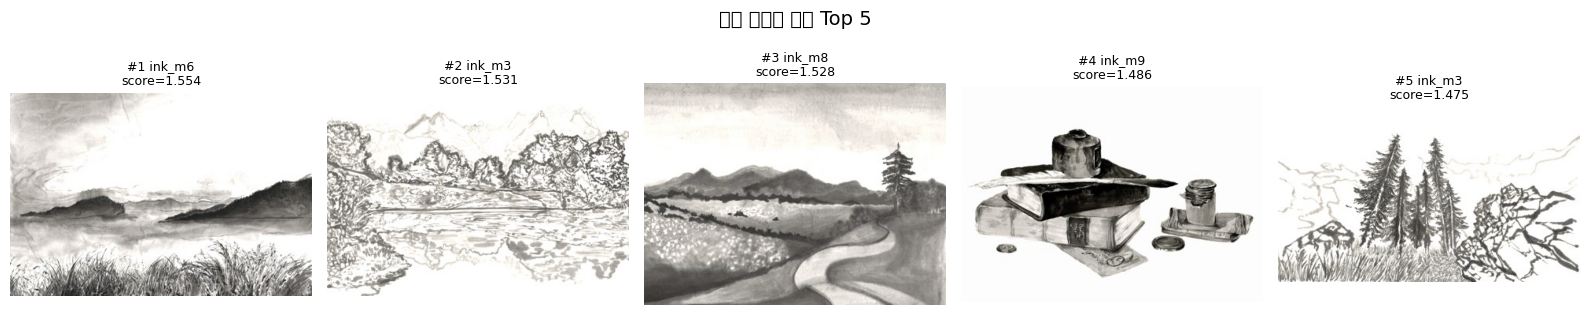

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_results(indices, scores, title, columns=5):
    rows = (len(indices) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(3.2 * columns, 3.5 * rows))
    axes = np.asarray(axes).reshape(-1)
    corpus = services.search_index.corpus
    for axis in axes:
        axis.axis("off")
    for rank, (index, score) in enumerate(zip(indices, scores), 1):
        axis = axes[rank - 1]
        with Image.open(corpus.paths[index]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"#{rank} {corpus.styles[index]}\nscore={score:.3f}",
            fontsize=9,
        )
        axis.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_results(
    state["final_indices"],
    state["final_scores"],
    "최종 스타일 검색 Top 5",
)

In [21]:
print("[최종 점수 분해]")
for row in result["final_score_breakdown"]:
    print(
        f"{row['style']:24s}",
        f"text={row['text_style_score']:+.3f}",
        f"clip={row['clip_prototype_score']:+.3f}",
        f"gram={row['gram_prototype_score']:+.3f}",
        f"final={row['final_score']:+.3f}",
    )

print("\n[노드 실행 기록]")
for event in result["audit_log"]:
    print(
        event["node"],
        event["outcome"],
        f"{event['elapsed_ms']:.1f}ms",
        event.get("detail", ""),
    )

[최종 점수 분해]
ink_m6                   text=+0.265 clip=+0.865 gram=+0.983 final=+1.554
ink_m3                   text=+0.268 clip=+0.870 gram=+0.964 final=+1.531
ink_m8                   text=+0.270 clip=+0.856 gram=+0.968 final=+1.528
ink_m9                   text=+0.260 clip=+0.866 gram=+0.980 final=+1.486
ink_m3                   text=+0.261 clip=+0.869 gram=+0.973 final=+1.475

[노드 실행 기록]
rewrite_query success 5.7ms strategy=canonical_fallback cache_hit=False attempts=1
text_search success 20.6ms contract valid
extract_image_features success 0.3ms contract valid
final_image_search success 9.6ms contract valid


## 8. 같은 질의 Warm Cache 확인

`llm` 모드에서는 첫 실행 후 동일 문장을 다시 실행합니다. 두 번째 결과의
`cache_hit=True`, `attempts=0`을 확인해야 합니다. `rewrite_source=llm`은 캐시에 저장된
원래 생성 출처이므로 캐시 여부는 반드시 diagnostics로 판단합니다.

In [22]:
warm_state = run_final_style_search(
    graph,
    STYLE_QUERY,
    SEARCH_CONFIG,
    REWRITE_POLICY,
)
warm_result = public_final_result(warm_state)
print("Warm rewrite 진단:", warm_result["rewrite_diagnostics"])
for event in warm_result["audit_log"]:
    print(event["node"], f"{event['elapsed_ms']:.1f}ms", event.get("detail", ""))

Warm rewrite 진단: {'configured_mode': 'llm', 'strategy_used': 'canonical_fallback', 'cache_hit': False, 'attempts': 1, 'model_id': 'gpt-5.6-luna'}
rewrite_query 8.4ms strategy=canonical_fallback cache_hit=False attempts=1
text_search 17.8ms contract valid
extract_image_features 0.3ms contract valid
final_image_search 15.8ms contract valid


## 9. 다른 검색어 반복 실행

특징 인덱스와 그래프는 다시 만들지 않습니다. 결과는 방법별 폴더에 저장됩니다.

In [23]:
def search_style(user_query, show=True):
    current_state = run_final_style_search(
        graph,
        user_query,
        SEARCH_CONFIG,
        REWRITE_POLICY,
    )
    current_result = public_final_result(current_state)
    output_path = RESULTS_DIR / f"search_{current_result['request_id']}.json"
    output_path.write_text(
        json.dumps(current_result, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    if current_result["status"] != "success":
        print("실패:", current_result["errors"])
        return current_state
    print("원문:", user_query)
    print("재작성:", current_result["rewrite_diagnostics"])
    print("스타일 문장:", current_result["query_parts"]["style_prompt_en"])
    print("최종 스타일:", current_result["final_styles"])
    if show:
        show_results(
            current_state["final_indices"],
            current_state["final_scores"],
            user_query,
        )
    return current_state

# 사용 예시
# another_state = search_style("거친 목탄 스케치 스타일의 고양이")

## 10. 종료 전 확인

- 검색 노드는 `style_prompt_en`만 사용합니다.
- `rewrite_cache_hit`, `rewrite_attempts`, 노드별 지연시간이 결과 JSON에 남습니다.
- `llm`, `canonical_first`, `canonical_only`는 서로 다른 방법으로 기록합니다.
- 단일 예시 성공을 성능 개선으로 해석하지 않습니다.
- 최종 판정은 같은 daypack_v2에서 Style-Macro mAP@5와 대응 95% 구간으로 합니다.